In [1]:
#!/usr/bin/env python
"""
LeafletFA Model Evaluation Script - Fixed Batched Evaluation
Evaluates trained models on test data using mini-batches with proper mask handling.
"""

import os, sys, glob, pickle, gzip
import numpy as np
import pandas as pd
import torch
import mudata as mu
from scipy import sparse
from scipy.stats import spearmanr
from datetime import datetime
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
torch.set_default_tensor_type("torch.cuda.FloatTensor" if torch.cuda.is_available() else "torch.FloatTensor")
torch.manual_seed(0)
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

sys.path.append("/gpfs/commons/home/kisaev/Leaflet-private/src/")
import BetaDirichletFactor.LeafletFA as LeafletFA

Device: cpu


/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1728241823685/work/torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


Torch Version: 2.4.1.post300
CUDA Version: 12.0


In [2]:
# load NMF results
nmf_path = "/gpfs/commons/home/kisaev/Leaflet-analysis/Mouse_Splicing_Foundation/Figures/FIGURE2/nmf_imputation_results_comprehensive.csv"
nmf_results = pd.read_csv(nmf_path)
nmf_results.head()

,n_components,mask_percent,n_masked_values,pearson_r,pearson_p,spearman_r,spearman_p,l1_mae,rmse,test_path
0,20,25%,34420861,0.291675,0.0,0.235445,0.0,0.511491,0.592113,MASKED_25_PERCENT_test_30_70_model_ready_combi...
1,20,50%,68872440,0.291218,0.0,0.235105,0.0,0.588581,0.655275,MASKED_50_PERCENT_test_30_70_model_ready_combi...
2,20,75%,103308614,0.290297,0.0,0.234621,0.0,0.668943,0.728115,MASKED_75_PERCENT_test_30_70_model_ready_combi...
3,30,25%,34420861,0.292424,0.0,0.235919,0.0,0.510578,0.591218,MASKED_25_PERCENT_test_30_70_model_ready_combi...
4,30,50%,68872440,0.291848,0.0,0.235483,0.0,0.587947,0.654654,MASKED_50_PERCENT_test_30_70_model_ready_combi...


In [3]:
# Load in results from using pre-trained model on train to impute values in test and assess performance 
# comparing imputed values to true values for ATSEs that were explicitly masked in test

results_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/MODEL_OUTPUT/batch_evaluation_1125"
all_results = [] 

for run_name in os.listdir(results_path):
    run_path = os.path.join(results_path, run_name)
    if os.path.isdir(run_path):
        result_file = os.path.join(run_path, f"{run_name}_combined_masking_results.csv")
        results_df = pd.read_csv(result_file)
        all_results.append(results_df)

all_results_df = pd.concat(all_results)

In [4]:
all_results_df["K_used"].value_counts()

K_used
20    24
30    18
50    15
Name: count, dtype: int64

In [5]:
# print all the columns in all_results_df
print(all_results_df.columns)

Index(['model_path', 'pearson', 'spearman', 'num_masked_values', 'K_used',
       'num_batches', 'l1_loss', 'rmse', 'masking_percentage', 'run_name',
       'run_idx', 'input_conc', 'junc_specific_prior', 'delta_fixed', 'K',
       'waypoints_use', 'batch_size', 'num_passes', 'num_epochs_first',
       'num_epochs_later', 'ELBO_num_particles', 'num_samples', 'gamma',
       'min_delta', 'lr', 'patience', 'max_junctions', 'n_waypoints',
       'n_pca_components', 'n_dim_components', 'metacell_size',
       'recompute_pca', 'estimated_total_batches', 'num_inits', 'num_epochs'],
      dtype='object')


In [16]:
all_results_df[all_results_df["K_used"] == 20].sort_values(by="num_masked_values")

,model_path,pearson,spearman,num_masked_values,K_used,num_batches,l1_loss,rmse,masking_percentage,run_name,...,patience,max_junctions,n_waypoints,n_pca_components,n_dim_components,metacell_size,recompute_pca,estimated_total_batches,num_inits,num_epochs
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.834604,0.795576,73071166,20,11,0.153858,0.239573,25,run_10,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.832404,0.790478,73071166,20,11,0.154230,0.240664,25,run_18,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.826427,0.791568,73071166,20,11,0.167141,0.244757,25,run_0,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.833941,0.798669,73071166,20,11,0.175762,0.243041,25,run_1,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.815019,0.777357,73071166,20,11,0.149047,0.247728,25,run_20,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.525090,0.517427,73071166,20,11,0.368785,0.397233,25,run_11,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.832071,0.793706,73071166,20,11,0.139325,0.237075,25,run_19,...,5,5,20,20,20,30,True,185,1,NaN
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.816812,0.782224,73071166,20,11,0.221380,0.268062,25,run_2,...,5,5,20,20,20,30,True,185,1,NaN
1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.814788,0.777364,146211866,20,11,0.149062,0.247856,50,run_20,...,5,5,20,20,20,30,True,185,1,NaN
1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.831922,0.793530,146211866,20,11,0.139390,0.237160,50,run_19,...,5,5,20,20,20,30,True,185,1,NaN


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


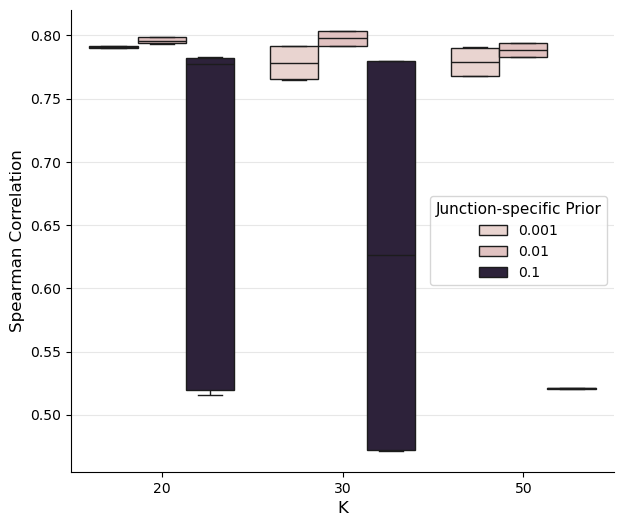

In [18]:
# Make a boxplot of spearman correlation for each K, colored by junction-specific prior

plt.figure(figsize=(7, 6))
sns.boxplot(x='K', y='spearman', data=all_results_df, hue="lr")
plt.xlabel('K')
plt.ylabel('Spearman Correlation')
plt.legend(title='Junction-specific Prior')
plt.show()

In [21]:
# Examine the data structure
print("Data shape:", all_results_df.shape)
print("\nUnique K values:", sorted(all_results_df['K_used'].unique()))
print("\nAvailable grouping variables:")
grouping_vars = ['masking_percentage', 'input_conc', 'junc_specific_prior', 'lr']
for var in grouping_vars:
    if var in all_results_df.columns:
        unique_vals = sorted(all_results_df[var].unique())
        print(f"  {var}: {unique_vals}")
print("\nSample of data:")
print(all_results_df[['K_used', 'masking_percentage', 'input_conc', 'junc_specific_prior', 'lr', 'l1_loss', 'rmse', 'spearman']].head(10))

# Set publication-ready style
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})

# CONFIGURABLE PLOTTING FUNCTION
def plot_metrics_vs_K(grouping_variable='masking_percentage', save_suffix=''):
    """
    Plot model performance metrics vs K grouped by a specified variable.
    
    Parameters:
    - grouping_variable: Column name to group by ('masking_percentage', 'input_conc', 'junc_specific_prior', 'lr')
    - save_suffix: Suffix to add to saved file names
    """
    
    # Get unique values for the grouping variable
    group_values = sorted(all_results_df[grouping_variable].unique())
    colors = sns.color_palette("Set2", len(group_values))
    
    # Create publication-ready plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Model Performance Metrics vs K across {grouping_variable.replace("_", " ").title()}', 
                 fontweight='bold', y=1.02)
    
    # Metrics to plot
    metrics = ['l1_loss', 'rmse', 'spearman']
    metric_labels = ['L1 Loss', 'RMSE', 'Spearman Correlation']
    metric_titles = ['L1 Loss vs K', 'RMSE vs K', 'Spearman Correlation vs K']
    
    for idx, (metric, label, title) in enumerate(zip(metrics, metric_labels, metric_titles)):
        ax = axes[idx]
        
        # Create boxplot with grouping variable as hue
        sns.boxplot(data=all_results_df, x='K_used', y=metric, hue=grouping_variable, 
                    ax=ax, palette=colors, width=0.7)
        
        # Add mean lines for each group
        for i, group_val in enumerate(group_values):
            subset = all_results_df[all_results_df[grouping_variable] == group_val]
            if not subset.empty:
                mean_vals = subset.groupby('K_used')[metric].mean()
                k_values = mean_vals.index
                ax.plot(range(len(k_values)), mean_vals.values, 'o-', 
                       color=colors[i], linewidth=2.5, markersize=7, alpha=0.8)
        
        ax.set_xlabel('K (Number of Factors)', fontweight='bold')
        ax.set_ylabel(label, fontweight='bold')
        ax.set_title(title, fontweight='bold')
        
        # Customize legend
        if idx == 2:  # Only show legend on the last plot
            legend_title = grouping_variable.replace('_', ' ').title()
            ax.legend(title=legend_title, title_fontsize=11, bbox_to_anchor=(1.05, 1), loc='upper left')
        else:
            ax.get_legend().remove()
    
    plt.tight_layout()
    plt.show()
    
    # Save the figure
    filename_base = f'model_performance_metrics_vs_K_{grouping_variable}{save_suffix}'
    plt.savefig(f'{filename_base}.pdf', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.savefig(f'{filename_base}.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print(f"Plots saved as: {filename_base}.pdf and {filename_base}.png")

Data shape: (57, 35)

Unique K values: [20, 30, 50]

Available grouping variables:
  masking_percentage: [25, 50, 75]
  input_conc: [inf, nan]
  junc_specific_prior: [False, True]
  lr: [0.001, 0.01, 0.1]

Sample of data:
   K_used  masking_percentage  input_conc  junc_specific_prior    lr  \
0      30                  75         inf                 True  0.10   
1      30                  50         inf                 True  0.10   
2      30                  25         inf                 True  0.10   
0      20                  75         NaN                 True  0.10   
1      20                  50         NaN                 True  0.10   
2      20                  25         NaN                 True  0.10   
0      30                  75         NaN                False  0.01   
1      30                  50         NaN                False  0.01   
2      30                  25         NaN                False  0.01   
0      20                  75         inf                 

In [27]:
all_results_df["Likelihood"] = ""
# if inf then Binomial otherwise if NaN Beta-Binomial
all_results_df["Likelihood"] = all_results_df["input_conc"].apply(lambda x: "Binomial" if x == np.inf else "Beta-Binomial")
all_results_df["Likelihood"].value_counts()

Likelihood
Beta-Binomial    33
Binomial         24
Name: count, dtype: int64

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


PLOTTING BY LEARNING RATE


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


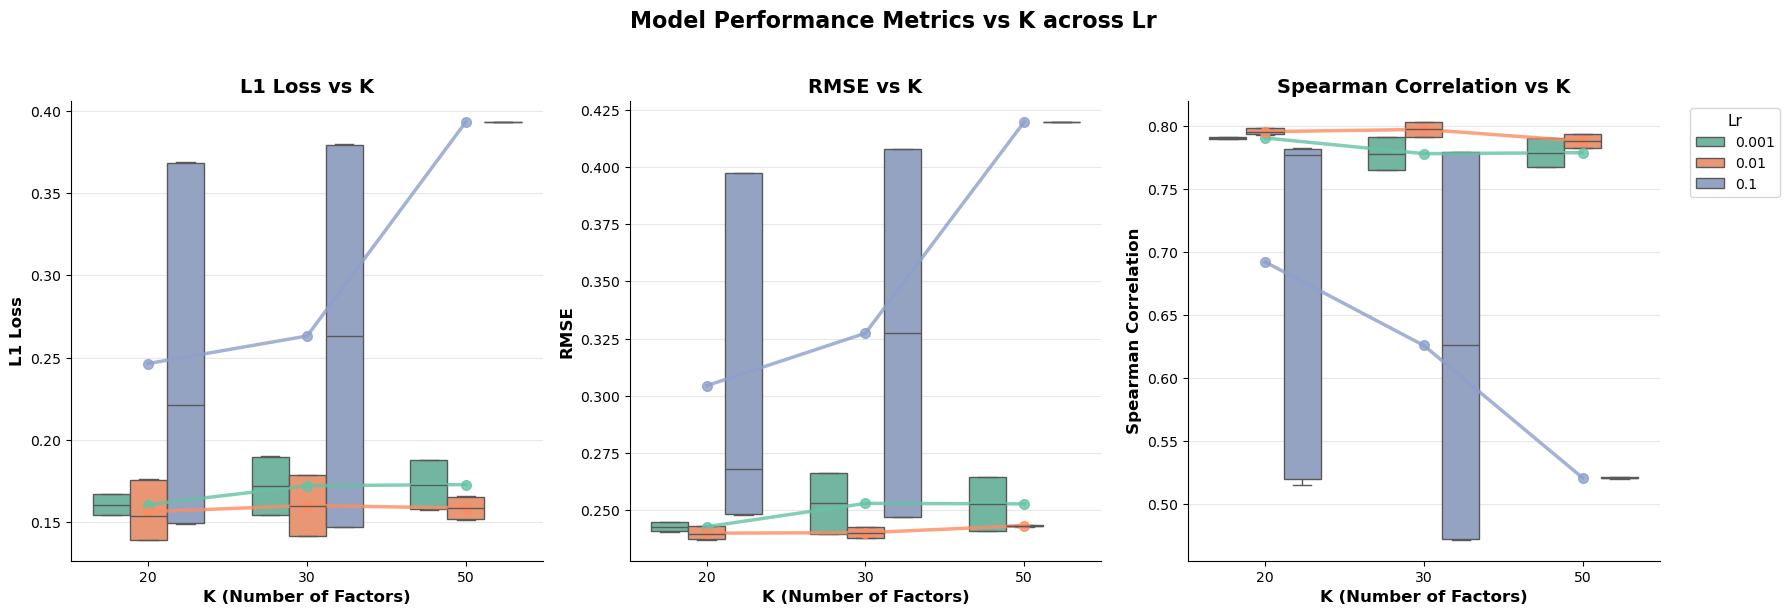

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Plots saved as: model_performance_metrics_vs_K_lr.pdf and model_performance_metrics_vs_K_lr.png

PLOTTING BY MASKING PERCENTAGE


Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


<Figure size 640x480 with 0 Axes>

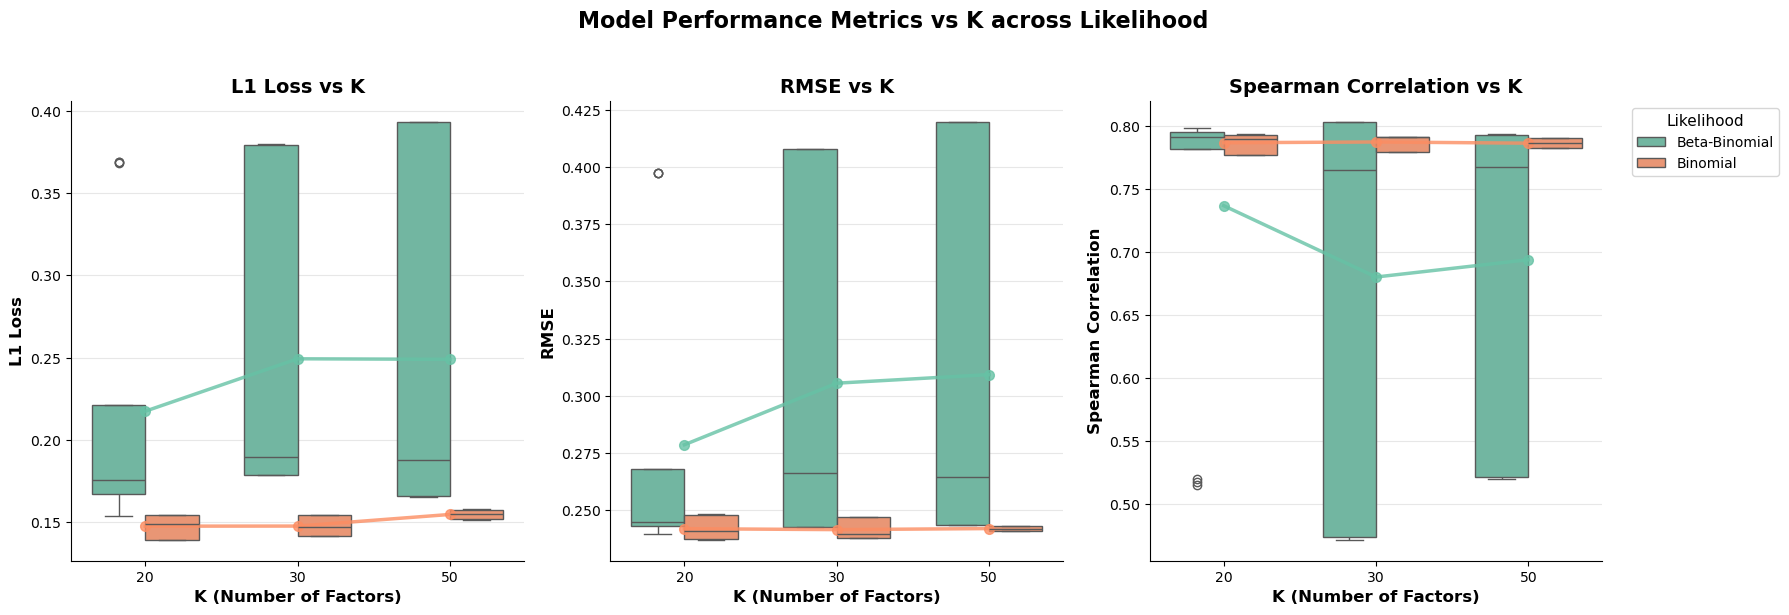

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/scratch/ipykernel_1110803/1864366752.py:57: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=all_results_df, x='K_used', y=metric, hue=grouping_variable,
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/scratch/ipykernel_1110803/1864366752.py:57: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.boxplot(data=all_results_df, x='K_used', y=metric, hue=grouping_va

Plots saved as: model_performance_metrics_vs_K_Likelihood.pdf and model_performance_metrics_vs_K_Likelihood.png

PLOTTING BY INPUT CONCENTRATION


<Figure size 640x480 with 0 Axes>

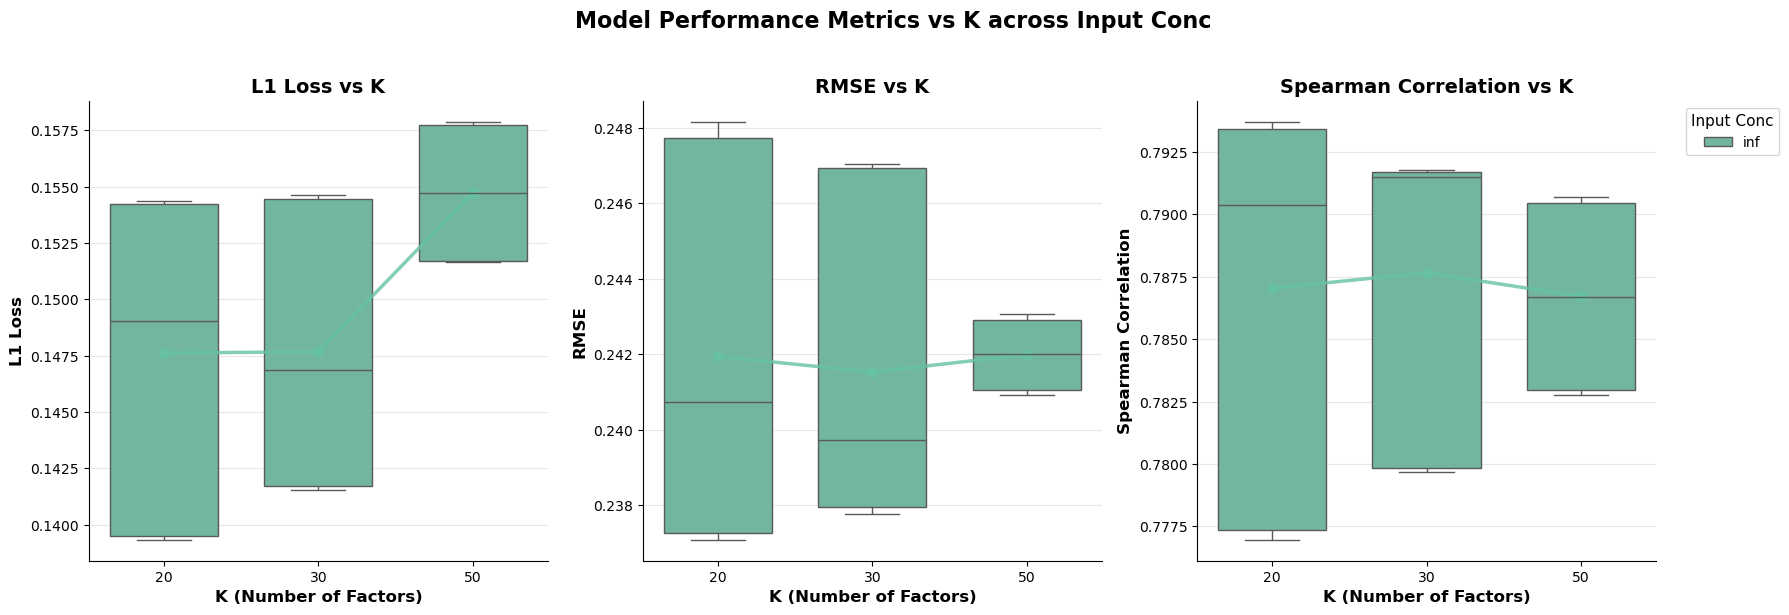

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings 

Plots saved as: model_performance_metrics_vs_K_input_conc.pdf and model_performance_metrics_vs_K_input_conc.png

PLOTTING BY JUNCTION-SPECIFIC PRIOR


<Figure size 640x480 with 0 Axes>

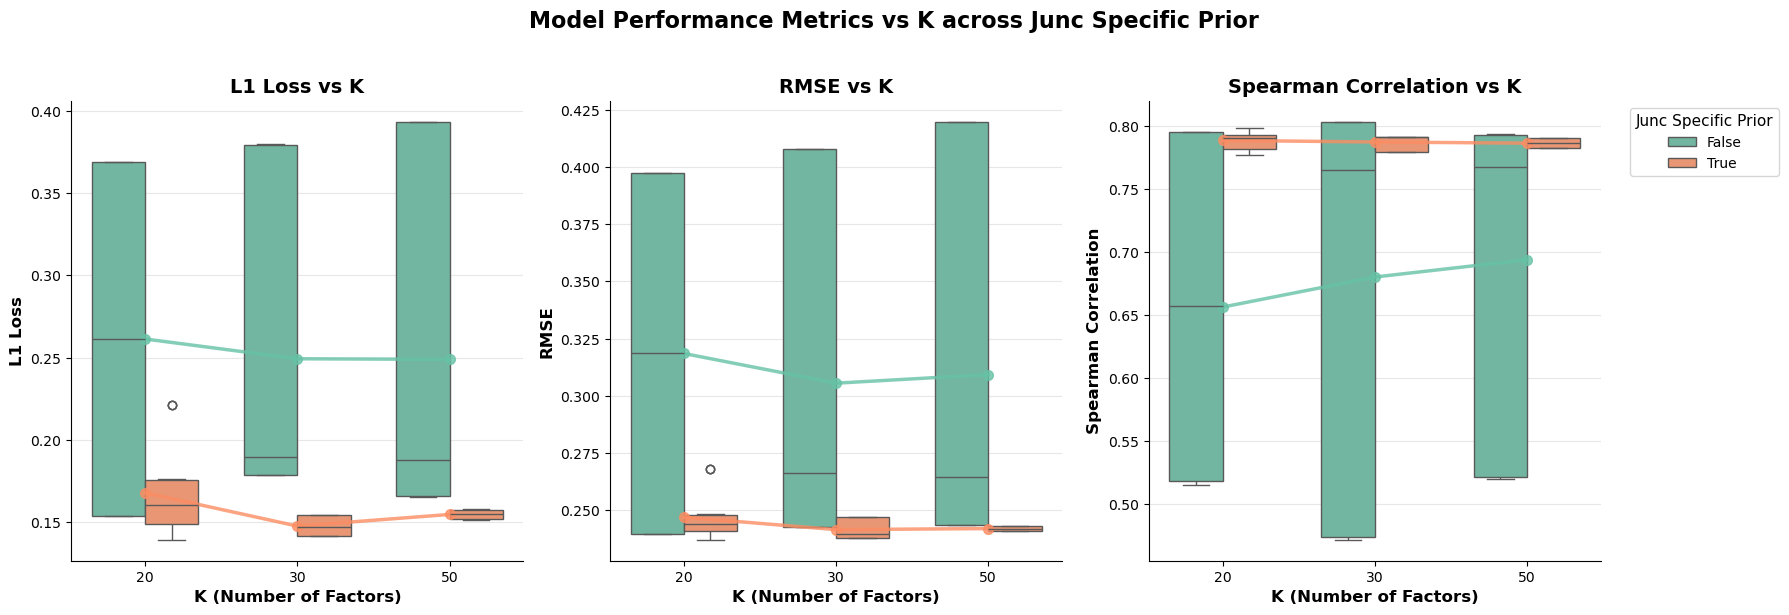

Plots saved as: model_performance_metrics_vs_K_junc_specific_prior.pdf and model_performance_metrics_vs_K_junc_specific_prior.png


<Figure size 640x480 with 0 Axes>

In [ ]:
# EXAMPLE USAGE - Change the grouping_variable to plot different comparisons:

# 1. Plot by learning rate (lr) - as requested
print("="*60)
print("PLOTTING BY LEARNING RATE")
print("="*60)
plot_metrics_vs_K(grouping_variable='lr')

# 2. Plot by masking percentage (original)
print("\n" + "="*60)
print("PLOTTING BY MASKING PERCENTAGE")
print("="*60)
plot_metrics_vs_K(grouping_variable='Likelihood')

In [37]:
all_results_df

,model_path,pearson,spearman,num_masked_values,K_used,num_batches,l1_loss,rmse,masking_percentage,run_name,...,max_junctions,n_waypoints,n_pca_components,n_dim_components,metacell_size,recompute_pca,estimated_total_batches,num_inits,num_epochs,Likelihood
0,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.816051,0.779662,219313777,30,11,0.146910,0.247053,75,run_23,...,5,30,20,20,30,True,185,1,NaN,Binomial
1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.816112,0.779758,146211866,30,11,0.146884,0.247010,50,run_23,...,5,30,20,20,30,True,185,1,NaN,Binomial
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.816235,0.779846,73071166,30,11,0.146828,0.246947,25,run_23,...,5,30,20,20,30,True,185,1,NaN,Binomial
0,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.817040,0.782371,219313777,20,11,0.221518,0.268057,75,run_2,...,5,20,20,20,30,True,185,1,NaN,Beta-Binomial
1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.816729,0.782578,146211866,20,11,0.221439,0.268106,50,run_2,...,5,20,20,20,30,True,185,1,NaN,Beta-Binomial
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.816812,0.782224,73071166,20,11,0.221380,0.268062,25,run_2,...,5,20,20,20,30,True,185,1,NaN,Beta-Binomial
0,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.837186,0.803502,219313777,30,11,0.178689,0.242652,75,run_13,...,5,30,20,20,30,True,185,1,NaN,Beta-Binomial
1,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.837413,0.803661,146211866,30,11,0.178613,0.242536,50,run_13,...,5,30,20,20,30,True,185,1,NaN,Beta-Binomial
2,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.837519,0.803743,73071166,30,11,0.178591,0.242483,25,run_13,...,5,30,20,20,30,True,185,1,NaN,Beta-Binomial
0,/gpfs/commons/groups/knowles_lab/Karin/Leaflet...,0.831778,0.793403,219313777,20,11,0.139497,0.237256,75,run_19,...,5,20,20,20,30,True,185,1,NaN,Binomial


Available likelihood-related columns: ['l1_loss', 'rmse', 'ELBO_num_particles', 'Likelihood']


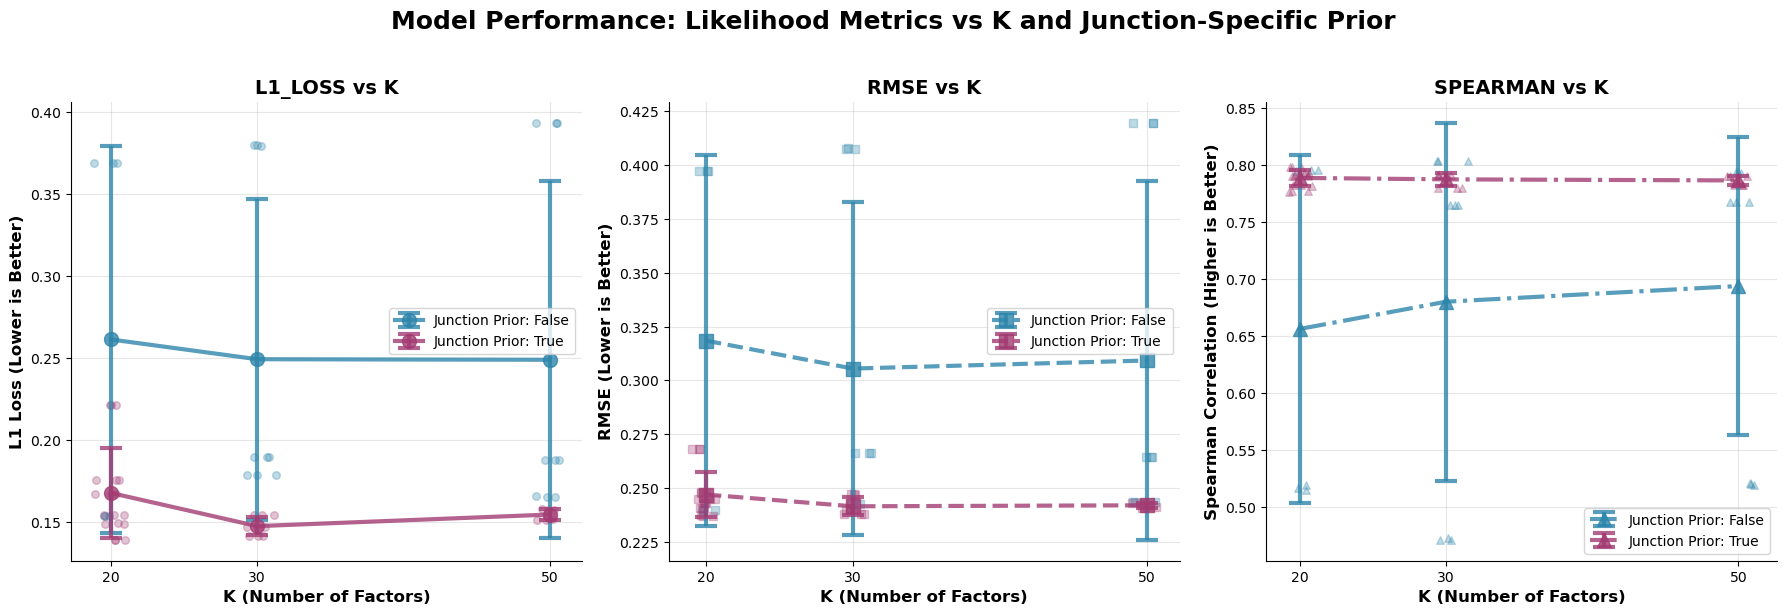

Publication plot saved as: publication_likelihood_junc_K_analysis.pdf/png

SUMMARY: Performance by K and Junction-Specific Prior
 K  Junction_Prior  n_samples  L1_Loss_mean  L1_Loss_std  RMSE_mean  RMSE_std  Spearman_mean  Spearman_std
20           False          6        0.2613       0.1176     0.3185    0.0863         0.6564        0.1522
20            True         18        0.1679       0.0275     0.2470    0.0103         0.7889        0.0073
30           False          9        0.2493       0.0977     0.3055    0.0773         0.6804        0.1570
30            True          9        0.1477       0.0056     0.2415    0.0042         0.7877        0.0059
50           False          9        0.2490       0.1087     0.3092    0.0833         0.6941        0.1305
50            True          6        0.1547       0.0033     0.2420    0.0011         0.7867        0.0042

Summary table saved to: publication_likelihood_junc_K_summary.csv


<Figure size 640x480 with 0 Axes>

In [35]:
# FINAL PUBLICATION PLOT: Likelihood + Junction-Specific Prior + K
# This creates a comprehensive plot showing the interaction between these three key variables

def create_publication_plot_likelihood_junc_K():
    """
    Create a publication-ready plot showing the relationship between 
    likelihood metrics, junction-specific prior, and K values.
    Single row layout with likelihood metrics (L1 loss, RMSE) and Spearman correlation.
    """
    
    # Check what likelihood-related columns are available
    likelihood_cols = [col for col in all_results_df.columns if any(term in col.lower() 
                      for term in ['elbo', 'likelihood', 'loss', 'rmse'])]
    print("Available likelihood-related columns:", likelihood_cols)
    
    # Set up the figure with single row layout
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Model Performance: Likelihood Metrics vs K and Junction-Specific Prior', 
                 fontsize=18, fontweight='bold', y=1.02)
    
    # Define colors for junction-specific prior
    junc_values = sorted(all_results_df['junc_specific_prior'].unique())
    colors = ['#2E86AB', '#A23B72']  # Blue for False, Pink for True
    color_map = dict(zip(junc_values, colors))
    
    # Metrics to plot (focusing on likelihood-related metrics and Spearman only)
    metrics = ['l1_loss', 'rmse', 'spearman']
    metric_labels = ['L1 Loss (Lower is Better)', 'RMSE (Lower is Better)', 
                    'Spearman Correlation (Higher is Better)']
    
    # Define line styles for different metrics (likelihood-based styling)
    line_styles = {
        'l1_loss': '-',      # Solid line for L1 loss
        'rmse': '--',        # Dashed line for RMSE  
        'spearman': '-.'     # Dash-dot line for Spearman
    }
    
    # Define markers for different metrics
    markers = {
        'l1_loss': 'o',      # Circle for L1 loss
        'rmse': 's',         # Square for RMSE
        'spearman': '^'      # Triangle for Spearman
    }
    
    for idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[idx]
        
        # Create separate plots for each junction-specific prior value
        for junc_val in junc_values:
            subset = all_results_df[all_results_df['junc_specific_prior'] == junc_val]
            if not subset.empty:
                # Group by K and calculate statistics
                grouped = subset.groupby('K_used')[metric].agg(['mean', 'std', 'count']).reset_index()
                
                # Plot with error bars using metric-specific line style and marker
                ax.errorbar(grouped['K_used'], grouped['mean'], yerr=grouped['std'],
                           marker=markers[metric], linewidth=3, markersize=10, capsize=8, capthick=3,
                           linestyle=line_styles[metric],
                           label=f'Junction Prior: {junc_val}', color=color_map[junc_val], alpha=0.8)
                
                # Add individual data points with some jitter for visibility
                jitter = np.random.normal(0, 0.5, len(subset))
                ax.scatter(subset['K_used'] + jitter, subset[metric], 
                          marker=markers[metric], color=color_map[junc_val], alpha=0.3, s=30)
        
        ax.set_xlabel('K (Number of Factors)', fontweight='bold', fontsize=12)
        ax.set_ylabel(label, fontweight='bold', fontsize=12)
        ax.set_title(f'{metric.upper()} vs K', fontweight='bold', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=10)
        
        # Set x-axis to show all K values
        k_values = sorted(all_results_df['K_used'].unique())
        ax.set_xticks(k_values)
        ax.set_xticklabels(k_values)
    
    plt.tight_layout()
    plt.show()
    
    # Save the publication plot
    plt.savefig('publication_likelihood_junc_K_analysis.pdf', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.savefig('publication_likelihood_junc_K_analysis.png', dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    
    print("Publication plot saved as: publication_likelihood_junc_K_analysis.pdf/png")
    
    # Create summary statistics table
    print("\n" + "="*80)
    print("SUMMARY: Performance by K and Junction-Specific Prior")
    print("="*80)
    
    summary_stats = []
    for k_val in sorted(all_results_df['K_used'].unique()):
        for junc_val in junc_values:
            subset = all_results_df[(all_results_df['K_used'] == k_val) & 
                                   (all_results_df['junc_specific_prior'] == junc_val)]
            if not subset.empty:
                stats = {
                    'K': k_val,
                    'Junction_Prior': junc_val,
                    'n_samples': len(subset),
                    'L1_Loss_mean': subset['l1_loss'].mean(),
                    'L1_Loss_std': subset['l1_loss'].std(),
                    'RMSE_mean': subset['rmse'].mean(),
                    'RMSE_std': subset['rmse'].std(),
                    'Spearman_mean': subset['spearman'].mean(),
                    'Spearman_std': subset['spearman'].std()
                }
                summary_stats.append(stats)
    
    summary_df = pd.DataFrame(summary_stats)
    summary_df = summary_df.round(4)
    print(summary_df.to_string(index=False))
    
    # Save summary table
    summary_df.to_csv('publication_likelihood_junc_K_summary.csv', index=False)
    print(f"\nSummary table saved to: publication_likelihood_junc_K_summary.csv")
    
    return summary_df

# Create the publication plot
summary_results = create_publication_plot_likelihood_junc_K()


In [43]:
df[["junc_specific_prior", "Likelihood", "K"]]

,junc_specific_prior,Likelihood,K
0,False,Beta-Binomial,30
1,False,Beta-Binomial,30
2,False,Beta-Binomial,30
0,True,Binomial,20
1,True,Binomial,20
2,True,Binomial,20
0,True,Binomial,30
1,True,Binomial,30
2,True,Binomial,30
0,False,Beta-Binomial,50


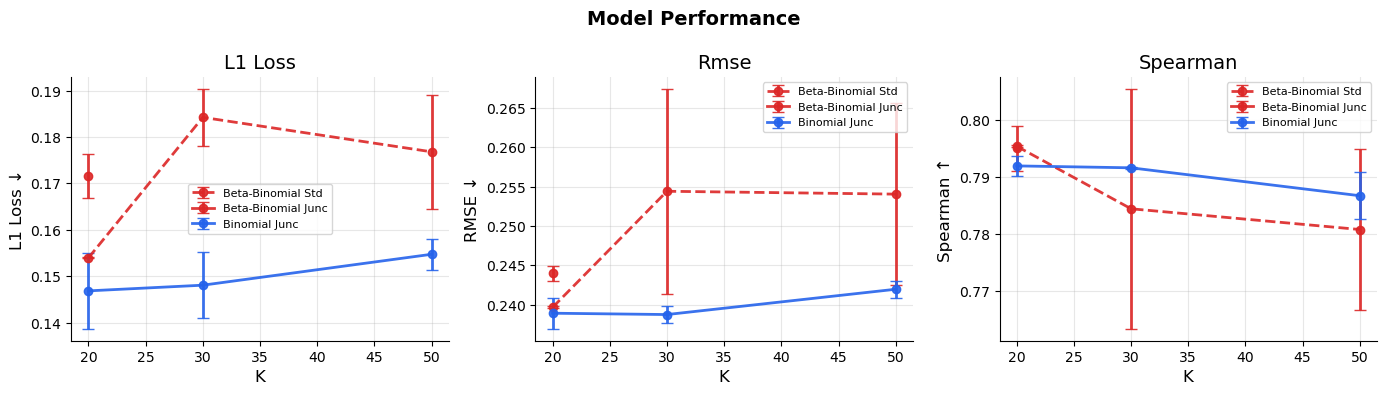


Best Configurations:


TypeError: unsupported format string passed to Series.__format__

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter lr=0.1 if exists
df = all_results_df[all_results_df.get('lr', 0) != 0.1].copy() if 'lr' in all_results_df.columns else all_results_df

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['l1_loss', 'rmse', 'spearman']
labels = ['L1 Loss ↓', 'RMSE ↓', 'Spearman ↑']

# Four combinations: 2 likelihoods × 2 junction settings
for ax, metric, label in zip(axes, metrics, labels):
    for likelihood in df['Likelihood'].unique():
        for junc in [False, True]:  # Explicitly iterate over False/True
            subset = df[(df['Likelihood'] == likelihood) & (df['junc_specific_prior'] == junc)]
            if not subset.empty:
                stats = subset.groupby('K_used')[metric].agg(['mean', 'std']).reset_index()
                
                # Set color and style for each combination
                color = '#2563eb' if likelihood == 'Binomial' else '#dc2626'  # Blue/Red
                linestyle = '-' if junc else '--'  # Solid for True, Dashed for False
                label_text = f"{likelihood} {'Junc' if junc else 'Std'}"
                
                ax.errorbar(stats['K_used'], stats['mean'], yerr=stats['std'],
                           marker='o', linestyle=linestyle, linewidth=2, capsize=4,
                           label=label_text, color=color, alpha=0.9)
    
    ax.set(xlabel='K', ylabel=label)
    ax.set_title(metric.replace('_', ' ').title())
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='best')

plt.suptitle('Model Performance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_plot.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Best configs
print("\nBest Configurations:")
for metric in metrics:
    if metric == 'spearman':
        best_idx = df[metric].idxmax()
    else:
        best_idx = df[metric].idxmin()
    best_row = df.loc[best_idx]
    print(f"{metric}: K={best_row['K_used']:.0f}, {best_row['Likelihood']}, Junc={best_row['junc_specific_prior']}, value={best_row[metric]:.4f}")